# Data Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load Data Sets

In [4]:
iemocap_train = pd.read_csv("../datasets/iemocap_train.csv")
meld_train = pd.read_csv("../datasets/meld_train.csv")

In [5]:
iemocap_train

,Dialogue_ID,Utterance_ID,Speaker,Emotion,Utterance
0,0,0,Ses01F_impro05_F,anger,Are there candid cameras? Is this that movie?...
1,0,1,Ses01F_impro05_M,neutral,"No, no. This is real."
2,0,2,Ses01F_impro05_F,neutral,So you'll give me money and then I'll get my bag?
3,0,3,Ses01F_impro05_M,neutral,"No. I'm just giving you money, the bag is gon..."
4,0,4,Ses01F_impro05_M,neutral,this is the only track record that we have and...
...,...,...,...,...,...
7239,819,3,Ses01M_script03_2_F,anger,I won't.
7240,819,4,Ses01M_script03_2_M,anger,Turn it off.
7241,819,5,Ses01M_script03_2_F,anger,Stop it. No. Go away.
7242,819,6,Ses01M_script03_2_M,anger,Amanda listen. Listen.


In [6]:
meld_train

,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,also I was the point person on my company’s tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731"
1,2,You must’ve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442"
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389"
3,4,So let’s talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572"
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917"
...,...,...,...,...,...,...,...,...,...,...,...
9984,10474,You or me?,Chandler,neutral,neutral,1038,13,2,3,"00:00:48,173","00:00:50,799"
9985,10475,"I got it. Uh, Joey, women don't have Adam's ap...",Ross,neutral,neutral,1038,14,2,3,"00:00:51,009","00:00:53,594"
9986,10476,"You guys are messing with me, right?",Joey,surprise,positive,1038,15,2,3,"00:01:00,518","00:01:03,520"
9987,10477,Yeah.,All,neutral,neutral,1038,16,2,3,"00:01:05,398","00:01:07,274"


In [7]:
### 1. BASIC DATA INFO ###
print("IEMOCAP Dataset Overview:")
print(iemocap_train.info())
print("\nMELD Dataset Overview:")
print(meld_train.info())

IEMOCAP Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7244 entries, 0 to 7243
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Dialogue_ID   7244 non-null   int64 
 1   Utterance_ID  7244 non-null   int64 
 2   Speaker       7244 non-null   object
 3   Emotion       7244 non-null   object
 4   Utterance     7243 non-null   object
dtypes: int64(2), object(3)
memory usage: 283.1+ KB
None

MELD Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sr No.        9989 non-null   int64 
 1   Utterance     9989 non-null   object
 2   Speaker       9989 non-null   object
 3   Emotion       9989 non-null   object
 4   Sentiment     9989 non-null   object
 5   Dialogue_ID   9989 non-null   int64 
 6   Utterance_ID  9989 non-null   int64 
 7   Sea

In [8]:
### 2. CHECK FOR MISSING VALUES ###
print("\nMissing Values in IEMOCAP:")
print(iemocap_train.isnull().sum())

print("\nMissing Values in MELD:")
print(meld_train.isnull().sum())


Missing Values in IEMOCAP:
Dialogue_ID     0
Utterance_ID    0
Speaker         0
Emotion         0
Utterance       1
dtype: int64

Missing Values in MELD:
Sr No.          0
Utterance       0
Speaker         0
Emotion         0
Sentiment       0
Dialogue_ID     0
Utterance_ID    0
Season          0
Episode         0
StartTime       0
EndTime         0
dtype: int64


/var/folders/cl/x4g3r0nj7qvb_h2ft5kt0zhw0000gn/T/ipykernel_11333/2136704380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=iemocap_train, x="Emotion", order=iemocap_train["Emotion"].value_counts().index, palette="coolwarm")
/var/folders/cl/x4g3r0nj7qvb_h2ft5kt0zhw0000gn/T/ipykernel_11333/2136704380.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meld_train, x="Emotion", order=meld_train["Emotion"].value_counts().index, palette="coolwarm")


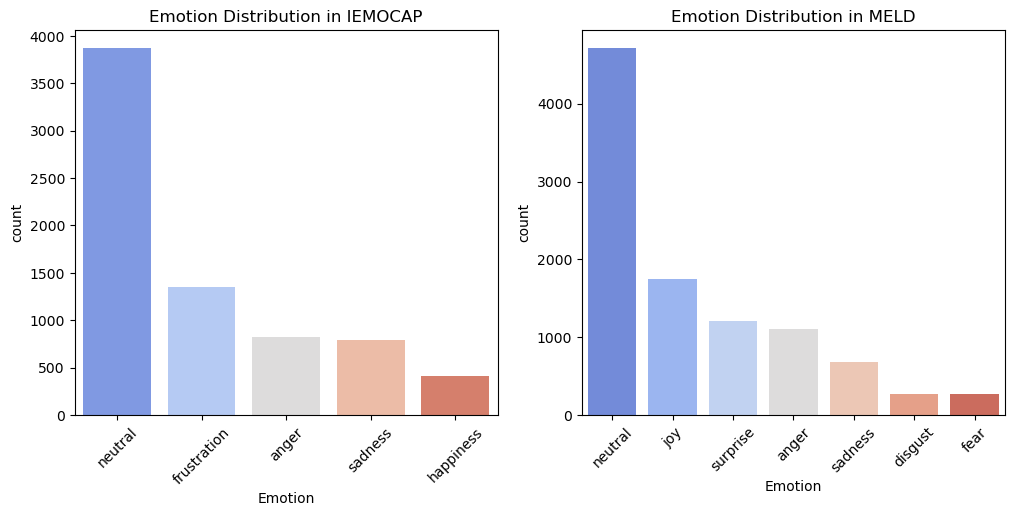

In [9]:
### 3. DISTRIBUTION OF EMOTIONS ###
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=iemocap_train, x="Emotion", order=iemocap_train["Emotion"].value_counts().index, palette="coolwarm")
plt.title("Emotion Distribution in IEMOCAP")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=meld_train, x="Emotion", order=meld_train["Emotion"].value_counts().index, palette="coolwarm")
plt.title("Emotion Distribution in MELD")
plt.xticks(rotation=45)

plt.show()

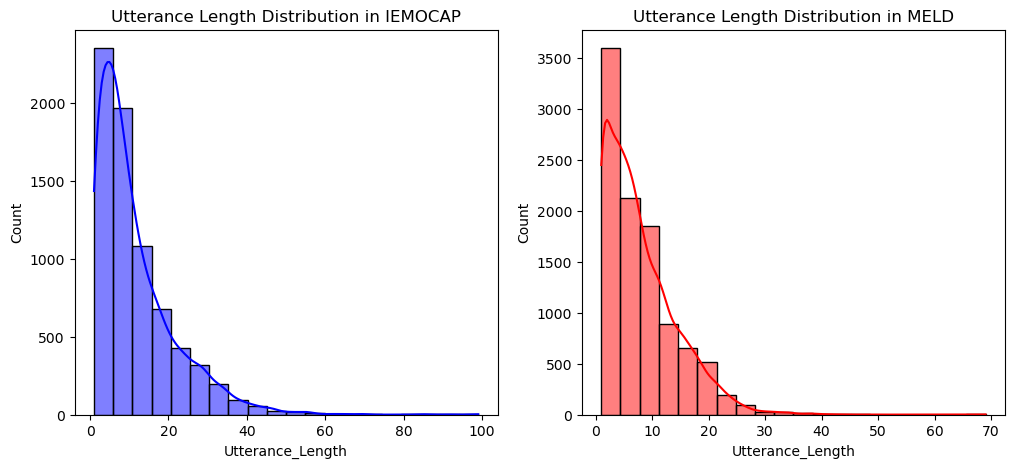

In [10]:
### 4. UTTERANCE LENGTH DISTRIBUTION ###
iemocap_train["Utterance_Length"] = iemocap_train["Utterance"].apply(lambda x: len(str(x).split()))
meld_train["Utterance_Length"] = meld_train["Utterance"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(iemocap_train["Utterance_Length"], bins=20, kde=True, color="blue")
plt.title("Utterance Length Distribution in IEMOCAP")

plt.subplot(1, 2, 2)
sns.histplot(meld_train["Utterance_Length"], bins=20, kde=True, color="red")
plt.title("Utterance Length Distribution in MELD")

plt.show()

In [11]:
print("Average utterance length for IEMOCAP: ", iemocap_train["Utterance_Length"].mean())
print("Average utterance length for MELD: ", meld_train["Utterance_Length"].mean())

Average utterance length for IEMOCAP:  11.448647156267256
Average utterance length for MELD:  7.948643507858645


In [12]:
print("Number of dialogues in IEMOCAP: ", iemocap_train["Dialogue_ID"].max())
print("Number of dialogues in MELD: ", meld_train["Dialogue_ID"].max())

Number of dialogues in IEMOCAP:  819
Number of dialogues in MELD:  1038


In [13]:
print("Average IEMOCAP dialogue length: ", iemocap_train.groupby("Dialogue_ID")["Utterance_ID"].max().mean())
print("Average MELD dialogue length: ", meld_train.groupby("Dialogue_ID")["Utterance_ID"].max().mean())

Average IEMOCAP dialogue length:  7.8341463414634145
Average MELD dialogue length:  8.719653179190752


In [14]:
### 5. NUMBER OF SPEAKERS ###
print("Unique Speakers in IEMOCAP:", iemocap_train["Speaker"].nunique())
print("Unique Speakers in MELD:", meld_train["Speaker"].nunique())

Unique Speakers in IEMOCAP: 302
Unique Speakers in MELD: 260


/var/folders/cl/x4g3r0nj7qvb_h2ft5kt0zhw0000gn/T/ipykernel_11333/705608538.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=iemocap_train[iemocap_train["Speaker"].isin(top_speakers)],
/var/folders/cl/x4g3r0nj7qvb_h2ft5kt0zhw0000gn/T/ipykernel_11333/705608538.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meld_train[meld_train["Speaker"].isin(top_speakers)],


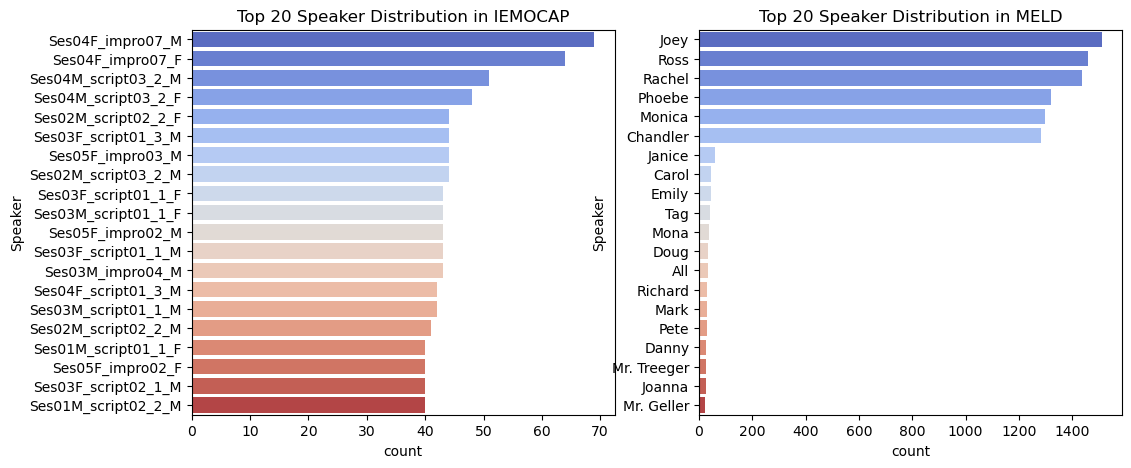

In [15]:
### 6. SPEAKER DISTRIBUTION ###
plt.figure(figsize=(12, 5))
N = 20  # Show top 20 speakers

plt.subplot(1, 2, 1)
top_speakers = iemocap_train["Speaker"].value_counts().nlargest(N).index
sns.countplot(data=iemocap_train[iemocap_train["Speaker"].isin(top_speakers)], 
              y="Speaker", 
              order=top_speakers, 
              palette="coolwarm")
plt.title("Top 20 Speaker Distribution in IEMOCAP")

plt.subplot(1, 2, 2)
top_speakers = meld_train["Speaker"].value_counts().nlargest(N).index
sns.countplot(data=meld_train[meld_train["Speaker"].isin(top_speakers)], 
              y="Speaker", 
              order=top_speakers, 
              palette="coolwarm")
plt.title("Top 20 Speaker Distribution in MELD")

plt.show()

In [16]:
def plot_transition_heatmap(df, dataset_name):
    """
    Plots the emotion transition heatmap for a given dataset, removing 'neutral' emotions.
    
    Args:
    - df (DataFrame): The dataset containing 'Dialogue_ID', 'Utterance_ID', and 'Emotion'.
    - dataset_name (str): Name of the dataset (MELD or IEMOCAP) for title.
    """
    # Remove Neutral emotion
    df = df[df["Emotion"] != "neutral"]

    # Sort dataset by dialogue sequence
    df = df.sort_values(by=["Dialogue_ID", "Utterance_ID"])

    # Shift emotion column to align current and next emotions
    df["Next_Emotion"] = df.groupby("Dialogue_ID")["Emotion"].shift(-1)

    # Drop NaN values (last utterance in each dialogue)
    transition_counts = df.dropna(subset=["Next_Emotion"]).groupby(["Emotion", "Next_Emotion"]).size().unstack(fill_value=0)

    # Remove 'Neutral' from next emotions as well
    transition_counts = transition_counts.drop(columns="neutral", errors="ignore")

    # Normalize row-wise to get transition probabilities
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    # Plot heatmap with square cells
    plt.figure(figsize=(8, 8))
    sns.heatmap(
        transition_probs, 
        annot=True, 
        cmap="Oranges", 
        fmt=".2f", 
        linewidths=0.5, 
        cbar=False, 
        square=True
    )

    plt.title(f"{dataset_name} Emotion Transition Probabilities", fontsize=14, fontweight="bold")
    plt.xlabel("Next Emotion", fontsize=12, fontweight="bold")
    plt.ylabel("Current Emotion", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

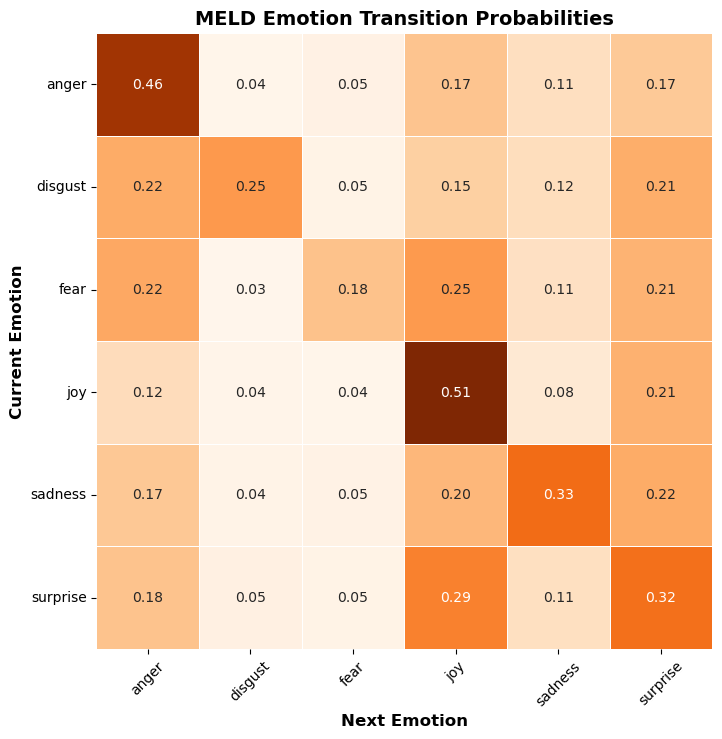

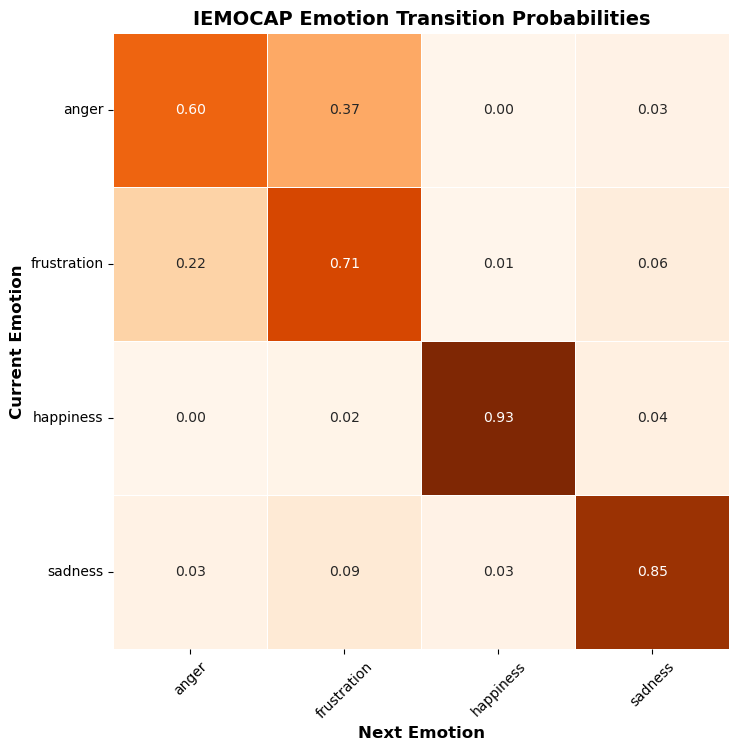

In [17]:
plot_transition_heatmap(meld_train, "MELD")
plot_transition_heatmap(iemocap_train, "IEMOCAP")

### IEMOCAP Dataset Comparison

In [18]:
# File paths
paths = {
    "Train": "../datasets/iemocap_train.csv",
    "Dev": "../datasets/iemocap_dev.csv",
    "Test": "../datasets/iemocap_test.csv"
}

# Initialize stats dictionary
stats = {
    "Conversations": {},
    "Utterances": {},
    "Speakers": {}
}

# Compute stats for each split
for split, path in paths.items():
    df = pd.read_csv(path)
    stats["Conversations"][split] = df["Dialogue_ID"].nunique()
    stats["Utterances"][split] = len(df)
    stats["Speakers"][split] = df["Speaker"].nunique()

# Add total column
for key in stats:
    stats[key]["Total"] = sum(stats[key].values())

# Convert to DataFrame
stats_df = pd.DataFrame(stats).T[["Train", "Dev", "Test", "Total"]]

In [19]:
stats_df

,Train,Dev,Test,Total
Conversations,820,92,229,1141
Utterances,7244,803,2040,10087
Speakers,302,146,232,680


In [22]:
# File paths
paths = {
    "Train": "iemocap_old/iemocap_train.csv",
    "Dev": "iemocap_old/iemocap_dev.csv",
    "Test": "iemocap_old/iemocap_test.csv"
}

# Initialize stats dictionary
stats = {
    "Conversations": {},
    "Utterances": {},
    "Speakers": {}
}

# Compute stats for each split
for split, path in paths.items():
    df = pd.read_csv(path)
    stats["Conversations"][split] = df["Dialogue_ID"].nunique()
    stats["Utterances"][split] = len(df)
    stats["Speakers"][split] = df["Speaker"].nunique()

# Add total column
for key in stats:
    stats[key]["Total"] = sum(stats[key].values())

# Convert to DataFrame
old_stats_df = pd.DataFrame(stats).T[["Train", "Dev", "Test", "Total"]]

In [23]:
old_stats_df

,Train,Dev,Test,Total
Conversations,108,12,31,151
Utterances,7160,783,2144,10087
Speakers,216,24,62,302
